In [7]:
"""
Análisis de Porosidad y Partículas

Este notebook aplica herramientas de segmentación a dos tareas comunes de imagen:
1. Análisis de porosidad: estimación de la fracción de una imagen ocupada por huecos o poros.
2. Análisis de partículas: identificación y medición de objetos sólidos individuales.
Estas son tareas cuantitativas estándar en imagen de materiales, tomografía, microscopía y otras aplicaciones científicas.
Objetivos de aprendizaje
- Crear máscaras binarias para poros y partículas.
- Estimar la fracción de porosidad a partir de imágenes segmentadas.
- Identificar partículas individuales con componentes conectados.
- Medir el tamaño y la forma de las partículas.
- Comprender cómo las opciones de segmentación afectan los resultados cuantitativos.
Contexto de la imagen científica
El análisis de porosidad y partículas se utiliza ampliamente en:
- Micro-CT de materiales porosos.
- Caracterización de partículas.
- Análisis de medios granulares.
- Cuantificación de defectos.
- Análisis de imágenes multifásicas.
"""

'\nAnálisis de Porosidad y Partículas\n\nEste notebook aplica herramientas de segmentación a dos tareas comunes de imagen:\n1. Análisis de porosidad: estimación de la fracción de una imagen ocupada por huecos o poros.\n2. Análisis de partículas: identificación y medición de objetos sólidos individuales.\nEstas son tareas cuantitativas estándar en imagen de materiales, tomografía, microscopía y otras aplicaciones científicas.\nObjetivos de aprendizaje\n- Crear máscaras binarias para poros y partículas.\n- Estimar la fracción de porosidad a partir de imágenes segmentadas.\n- Identificar partículas individuales con componentes conectados.\n- Medir el tamaño y la forma de las partículas.\n- Comprender cómo las opciones de segmentación afectan los resultados cuantitativos.\nContexto de la imagen científica\nEl análisis de porosidad y partículas se utiliza ampliamente en:\n- Micro-CT de materiales porosos.\n- Caracterización de partículas.\n- Análisis de medios granulares.\n- Cuantificación 

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import filters, morphology, measure, color, util
from skimage.draw import disk

In [9]:
def show_image(image, title="", cmap="gray", save_path=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def compare_images(images, titles, cmap="gray", figsize=(15, 5), save_path=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)

    if len(images) == 1:
        axes = [axes]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def save_dataframe_csv(df, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(save_path, index=False)


def porosity_fraction(mask):
    return mask.sum() / mask.size

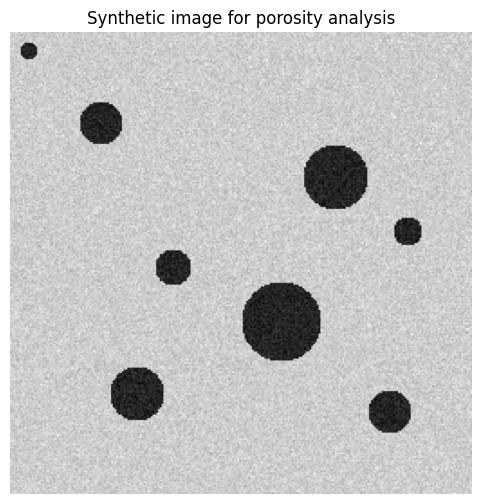

In [10]:
"""
Imagen sintética para análisis de porosidad
Comenzamos con una imagen sintética en escala de grises que representa una matriz sólida con poros oscuros.
En este ejemplo:
- Las regiones brillantes representan el material sólido.
- Las regiones circulares oscuras representan los poros.
Este caso controlado resulta útil porque la fase porosa es visualmente clara y fácil de segmentar.
"""
np.random.seed(42)

image_porosity = np.full((256, 256), 180, dtype=np.uint8)

pore_specs = [
    ((50, 50), 12),
    ((80, 180), 18),
    ((130, 90), 10),
    ((160, 150), 22),
    ((200, 70), 15),
    ((210, 210), 12),
    ((110, 220), 8),
    ((10, 10), 5),
]

for center, radius in pore_specs:
    rr, cc = disk(center, radius, shape=image_porosity.shape)
    image_porosity[rr, cc] = 60

# Add mild noise to make the image more realistic
noise = np.random.normal(loc=0, scale=8, size=image_porosity.shape)
image_porosity = np.clip(image_porosity + noise, 0, 255).astype(np.uint8)

show_image(
    image_porosity,
    "Synthetic image for porosity analysis",
    save_path="../figures/figures_porosity_particle_analysis/01_porosity_input_image.png"
)

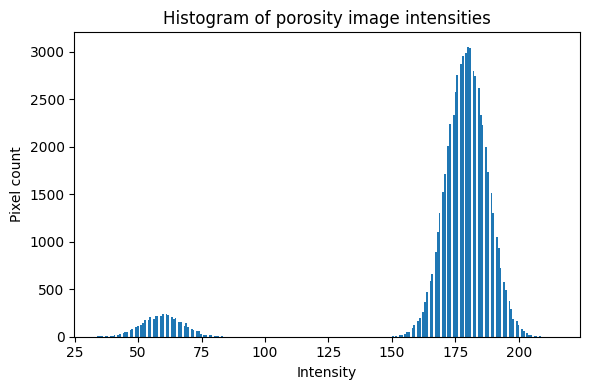

In [11]:
"""
Histograma de intensidades de escala de grises
El histograma nos ayuda a comprender si la fase de poros y la fase de matriz están suficientemente separadas para aplicar un threshold.
"""
plt.figure(figsize=(6, 4))
plt.hist(image_porosity.ravel(), bins=256)
plt.title("Histogram of porosity image intensities")
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.tight_layout()

os.makedirs("../figures/figures_porosity_particle_analysis", exist_ok=True)
plt.savefig(
    "../figures/figures_porosity_particle_analysis/02_porosity_histogram.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

Otsu threshold for pores: 89.00


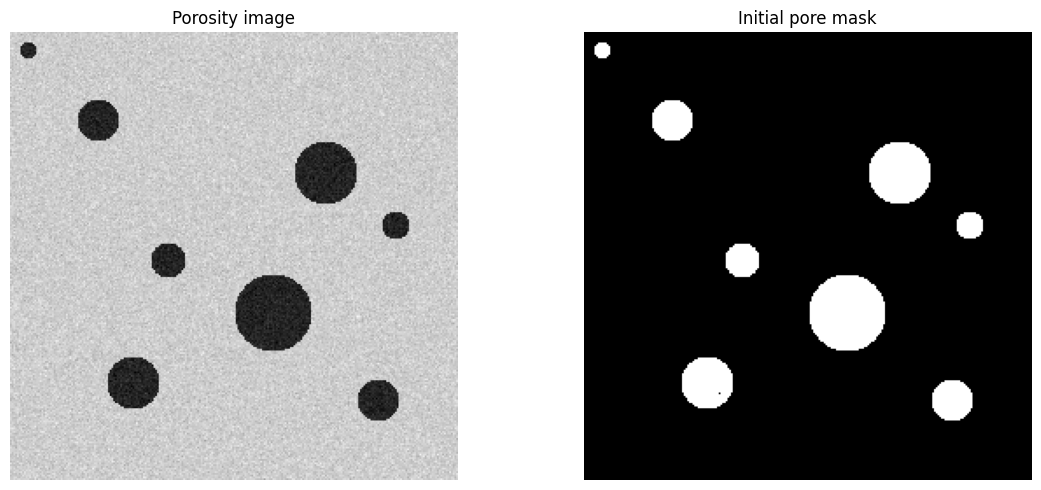

In [12]:
"""
Segmentación de poros
Dado que los poros son más oscuros que la matriz circundante, los segmentamos utilizando un threshold que selecciona los píxeles de baja intensidad.
Para este ejemplo sintético, el método de Otsu proporciona un threshold global simple.
"""
threshold_pores = filters.threshold_otsu(image_porosity)
pores_mask = image_porosity < threshold_pores

print(f"Otsu threshold for pores: {threshold_pores:.2f}")

compare_images(
    [image_porosity, pores_mask],
    ["Porosity image", "Initial pore mask"],
    figsize=(12, 5),
    save_path="../figures/figures_porosity_particle_analysis/03_initial_pore_segmentation.png"
)

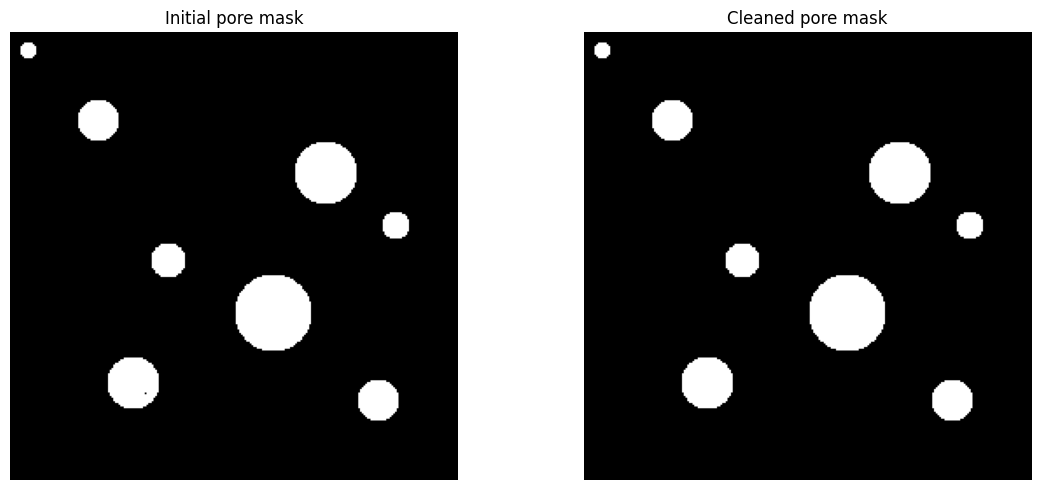

In [13]:
"""
Morphological cleanup de la mascara
Eliminamos pequeños artefactos en primer plano y rellenamos agujeros muy pequeños para mejorar la segmentación de los poros.
"""
pores_mask_clean = morphology.remove_small_objects(pores_mask, max_size=30)
pores_mask_clean = morphology.remove_small_holes(pores_mask_clean, max_size=20)

compare_images(
    [pores_mask, pores_mask_clean],
    ["Initial pore mask", "Cleaned pore mask"],
    figsize=(12, 5),
    save_path="../figures/figures_porosity_particle_analysis/04_clean_pore_mask.png"
)

In [14]:
"""
Estimación de la fracción de porosidad
Una estimación sencilla de la porosidad es la fracción de píxeles clasificados como poros:
\[
\phi = \frac{N_{\text{poro}}}{N_{\text{total}}}
\]
Esta es una estimación de la fracción de área en 2D. En imágenes volumétricas, la misma idea se extiende a los vóxeles y la fracción de volumen.
"""
phi_initial = porosity_fraction(pores_mask)
phi_clean = porosity_fraction(pores_mask_clean)

print(f"Porosity fraction (initial mask): {phi_initial:.4f}")
print(f"Porosity fraction (clean mask):   {phi_clean:.4f}")

Porosity fraction (initial mask): 0.0710
Porosity fraction (clean mask):   0.0710


Number of detected pores: 8


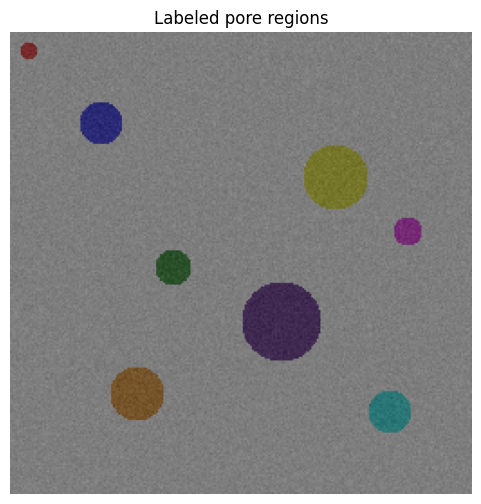

In [15]:
labels_pores = measure.label(pores_mask_clean, connectivity=2)

print(f"Number of detected pores: {labels_pores.max()}")

show_image(
    color.label2rgb(labels_pores, image=image_porosity, bg_label=0),
    "Labeled pore regions",
    cmap=None,
    save_path="../figures/figures_porosity_particle_analysis/05_labeled_pores.png"
)

In [16]:
props_pores = measure.regionprops_table(
    labels_pores,
    intensity_image=image_porosity,
    properties=[
        "label",
        "area",
        "centroid",
        "equivalent_diameter",
        "eccentricity",
        "perimeter",
        "solidity"
    ]
)

df_pores = pd.DataFrame(props_pores)
df_pores

,label,area,centroid-0,centroid-1,equivalent_diameter,eccentricity,perimeter,solidity
0,1,69.0,10.0,10.0,9.373021,0.0,27.313708,1.000000
1,2,437.0,50.0,50.0,23.588253,0.0,73.941125,0.982022
2,3,1005.0,80.0,180.0,35.771577,0.0,114.911688,0.984329
3,4,193.0,110.0,220.0,15.675944,0.0,48.970563,0.960199
4,5,305.0,130.0,90.0,19.706295,0.0,62.627417,0.974441
5,6,1513.0,160.0,150.0,43.890904,0.0,142.225397,0.979288
6,7,697.0,200.0,70.0,29.790065,0.0,95.597980,0.977560
7,8,437.0,210.0,210.0,23.588253,0.0,73.941125,0.982022


In [17]:
save_dataframe_csv(
    df_pores,
    "../figures/figures_porosity_particle_analysis/pores_region_properties.csv"
)

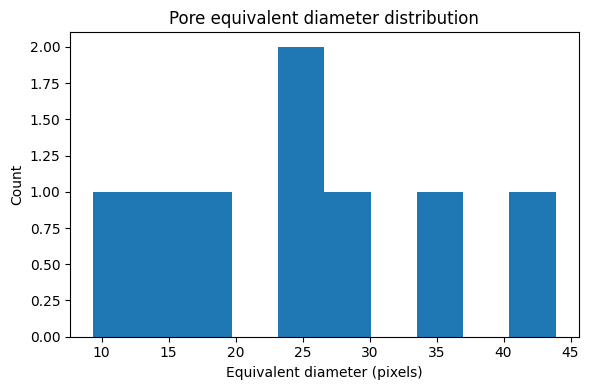

In [18]:
"""
Distribución del tamaño de los poros
La distribución del tamaño de los poros suele ser más informativa que un único valor de porosidad.
"""
plt.figure(figsize=(6, 4))
plt.hist(df_pores["equivalent_diameter"], bins=10)
plt.title("Pore equivalent diameter distribution")
plt.xlabel("Equivalent diameter (pixels)")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig(
    "../figures/figures_porosity_particle_analysis/06_pore_size_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

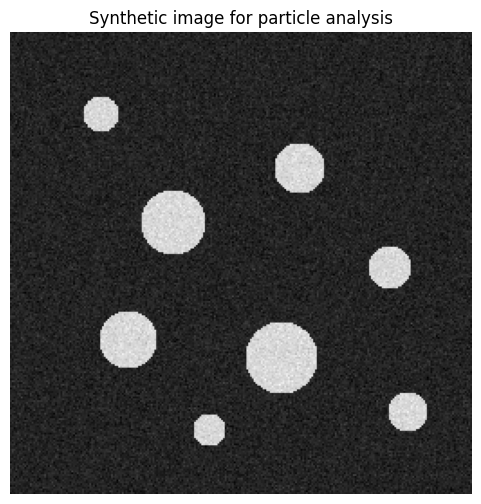

In [19]:
"""
Imagen sintética para análisis de partículas
Ahora creamos una segunda imagen sintética donde las partículas brillantes están incrustadas en un fondo más oscuro.
Esto simula una tarea común de segmentación en el análisis de imágenes de materiales: la identificación y caracterización de partículas o inclusiones individuales.
"""
image_particles = np.full((256, 256), 35, dtype=np.uint8)

particle_specs = [
    ((45, 50), 10),
    ((75, 160), 14),
    ((105, 90), 18),
    ((130, 210), 12),
    ((170, 65), 16),
    ((180, 150), 20),
    ((210, 220), 11),
    ((220, 110), 9),
]

for center, radius in particle_specs:
    rr, cc = disk(center, radius, shape=image_particles.shape)
    image_particles[rr, cc] = 210

noise_particles = np.random.normal(loc=0, scale=10, size=image_particles.shape)
image_particles = np.clip(image_particles + noise_particles, 0, 255).astype(np.uint8)

show_image(
    image_particles,
    "Synthetic image for particle analysis",
    save_path="../figures/figures_porosity_particle_analysis/07_particle_input_image.png"
)

Otsu threshold for particles: 77.00


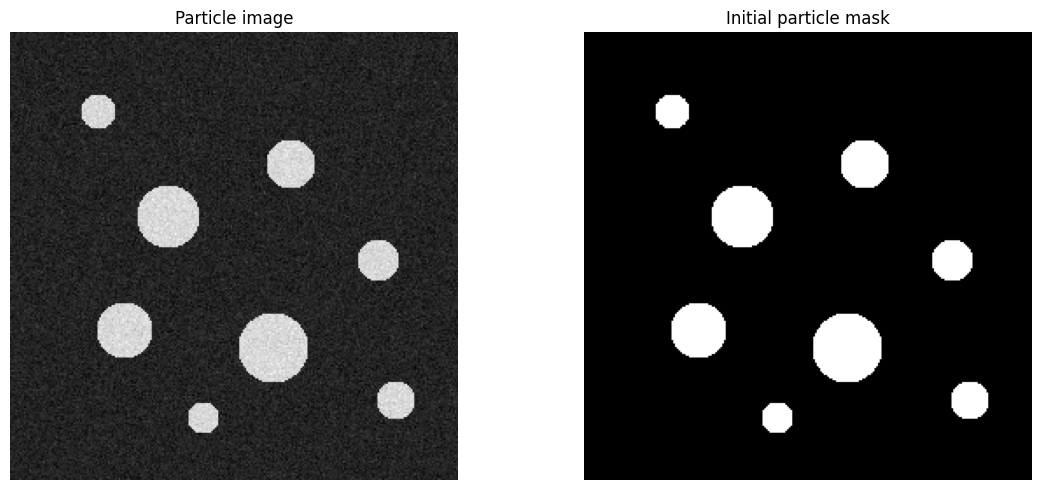

In [20]:
"""
Segmentación de partículas
En este caso, las partículas son más brillantes que el fondo, por lo que las segmentamos utilizando un threshold que selecciona los píxeles de alta intensidad.
"""
threshold_particles = filters.threshold_otsu(image_particles)
particles_mask = image_particles > threshold_particles

print(f"Otsu threshold for particles: {threshold_particles:.2f}")

compare_images(
    [image_particles, particles_mask],
    ["Particle image", "Initial particle mask"],
    figsize=(12, 5),
    save_path="../figures/figures_porosity_particle_analysis/08_initial_particle_segmentation.png"
)